In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
import seaborn as sns

In [4]:
df = pd.read_csv("C:/Users/lenovo/Documents/Dataset/Price.csv")

In [3]:
df.head(5)

,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
print(df.columns)

Index(['Carat(Weight of Daimond)', 'Cut(Quality)', 'Color', 'Clarity', 'Depth',
       'Table', 'Price(in US dollars)', 'X(length)', 'Y(width)', 'Z(Depth)'],
      dtype='str')


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5512\1719820613.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price(in US dollars)'], kde=True)


<Axes: xlabel='Price(in US dollars)', ylabel='Density'>

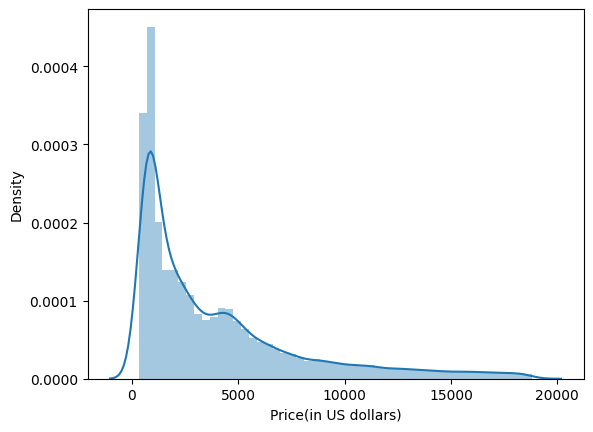

In [5]:
sns.distplot(df['Price(in US dollars)'], kde=True)

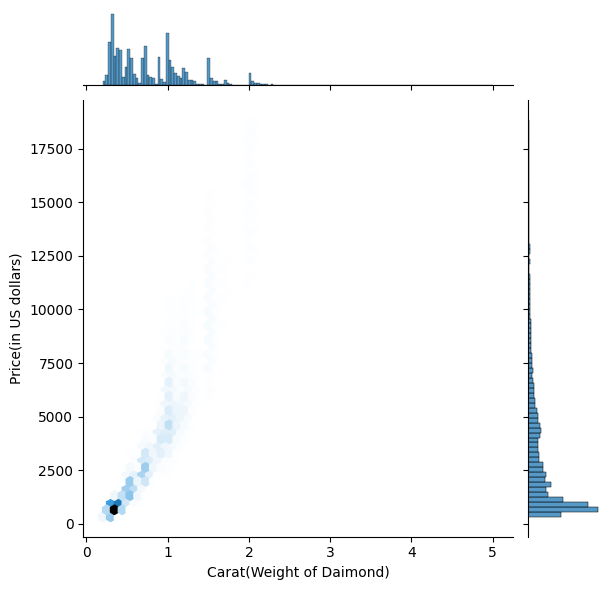

In [6]:
sns.jointplot(x='Carat(Weight of Daimond)', y='Price(in US dollars)', data=df, kind='hex')

<Axes: xlabel='Price(in US dollars)', ylabel='Density'>

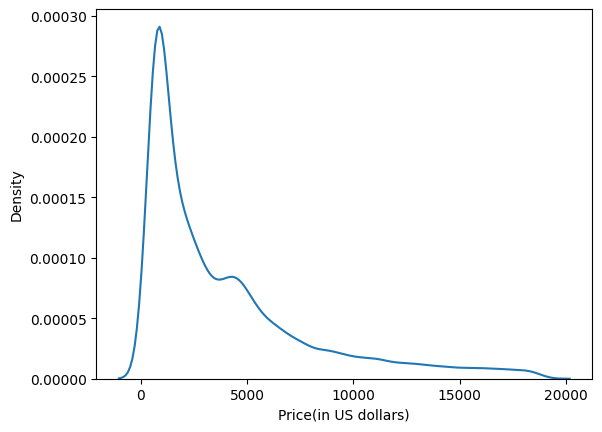

In [7]:
sns.kdeplot(df['Price(in US dollars)'])

<Axes: xlabel='Depth', ylabel='Price(in US dollars)'>

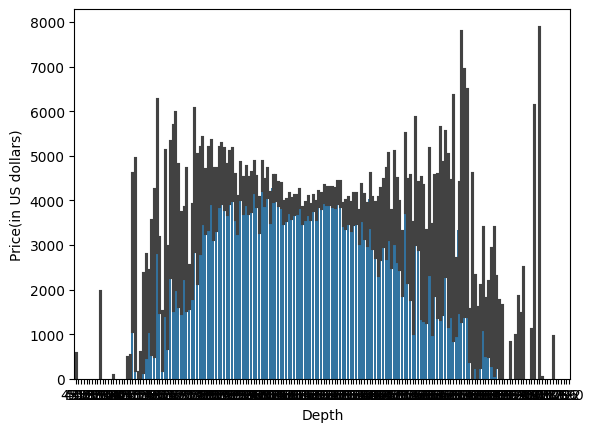

In [8]:
sns.barplot(x='Depth', y='Price(in US dollars)', data=df, estimator=np.std)

<Axes: xlabel='Cut(Quality)', ylabel='count'>

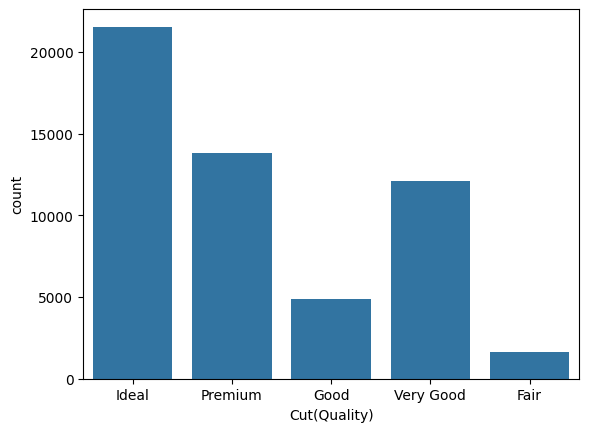

In [9]:
sns.countplot(x='Cut(Quality)', data=df)

In [10]:
df = pd.get_dummies(df, columns=['Cut(Quality)', 'Color'])

In [11]:
print(df.columns)

Index(['Carat(Weight of Daimond)', 'Clarity', 'Depth', 'Table',
       'Price(in US dollars)', 'X(length)', 'Y(width)', 'Z(Depth)',
       'Cut(Quality)_Fair', 'Cut(Quality)_Good', 'Cut(Quality)_Ideal',
       'Cut(Quality)_Premium', 'Cut(Quality)_Very Good', 'Color_D', 'Color_E',
       'Color_F', 'Color_G', 'Color_H', 'Color_I', 'Color_J'],
      dtype='str')


<Axes: xlabel='Clarity', ylabel='count'>

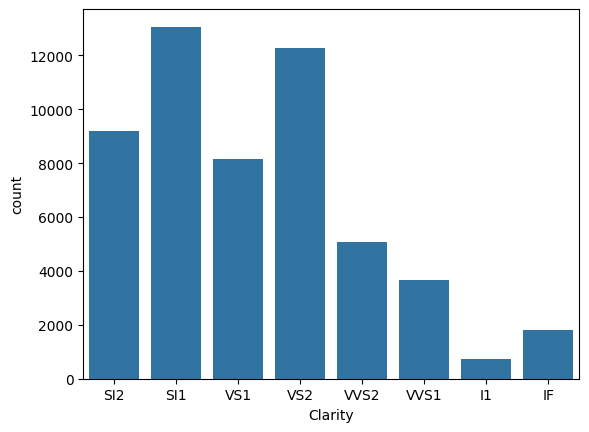

In [12]:
sns.countplot(x='Clarity', data=df)

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [14]:
np.random.seed(42)

In [15]:
le = LabelEncoder()
df['ideal_encoder'] = le.fit_transform(df['Clarity'])

In [16]:
df = df.drop(['Clarity'], axis=1)


In [17]:
X=df.drop('Price(in US dollars)', axis=1)
y=df['Price(in US dollars)']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error

In [22]:
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
print("\n" + "="*70)
print("MODEL PERFORMANCE")
print("="*70)
 
print("\nTRAINING SET:")
print(f"  R² Score:  {r2_train:.4f}")
print(f"  RMSE:      ${rmse_train:.2f}")
print(f"  MAE:       ${train_mae:.2f}")
print(f"  MSE:       ${mse_train:.2f}")
 
print("\nTEST SET:")
print(f"  R² Score:  {r2_test:.4f}")
print(f"  RMSE:      ${rmse_test:.2f}")
print(f"  MAE:       ${test_mae:.2f}")
print(f"  MSE:       ${mse_test:.2f}")
 
print(f"\nIntercept: ${model.intercept_:.2f}")



MODEL PERFORMANCE

TRAINING SET:
  R² Score:  0.8906
  RMSE:      $1324.86
  MAE:       $838.35
  MSE:       $1755257.96

TEST SET:
  R² Score:  0.8926
  RMSE:      $1294.06
  MAE:       $827.05
  MSE:       $1674603.44

Intercept: $8301.65


In [23]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)
print("TOP 10 features (by absolute coefficient)")
print(feature_importance.head(10).to_string(index=False))

TOP 10 features (by absolute coefficient)
                 Feature  Coefficient
Carat(Weight of Daimond) 11083.626314
                 Color_J -1420.147062
               X(length) -1174.387052
       Cut(Quality)_Fair  -897.992823
                 Color_D   658.363284
                 Color_I  -558.626040
                 Color_F   535.243872
                 Color_E   493.944861
                 Color_G   422.303506
      Cut(Quality)_Ideal   414.378173


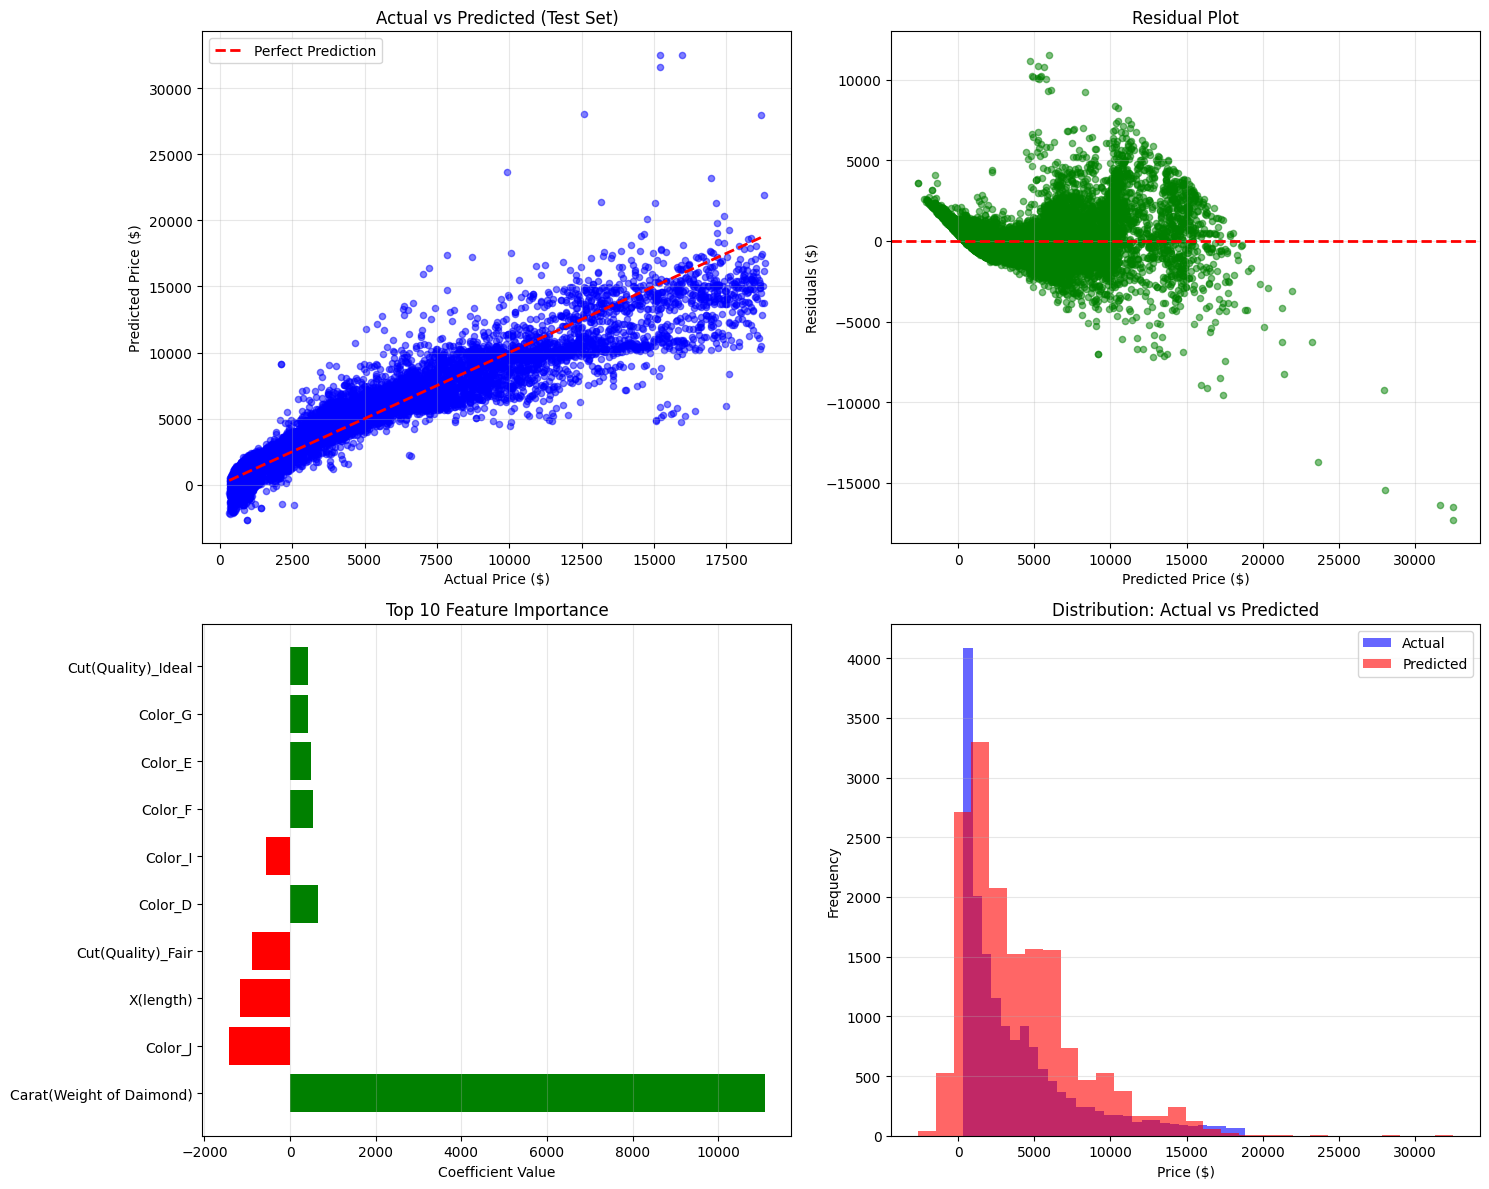

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes[0, 0].scatter(y_test, y_pred_test, alpha=0.5, s=20, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price ($)')
axes[0, 0].set_ylabel('Predicted Price ($)')
axes[0, 0].set_title('Actual vs Predicted (Test Set)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

residuals = y_test - y_pred_test
axes[0, 1].scatter(y_pred_test, residuals, alpha=0.5, s=20, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price ($)')
axes[0, 1].set_ylabel('Residuals ($)')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Feature Importance
top_10 = feature_importance.head(10)
colors = ['green' if x > 0 else 'red' for x in top_10['Coefficient']]
axes[1, 0].barh(top_10['Feature'], top_10['Coefficient'], color=colors)
axes[1, 0].set_xlabel('Coefficient Value')
axes[1, 0].set_title('Top 10 Feature Importance')
axes[1, 0].grid(True, alpha=0.3, axis='x')

axes[1, 1].hist(y_test, bins=30, alpha=0.6, label='Actual', color='blue')
axes[1, 1].hist(y_pred_test, bins=30, alpha=0.6, label='Predicted', color='red')
axes[1, 1].set_xlabel('Price ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution: Actual vs Predicted')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [25]:
print("\n" + "="*70)
print("EXAMPLE PREDICTIONS (First 5 test samples)")
print("="*70)
 
for i in range(min(5, len(y_test))):
    actual = y_test.iloc[i]
    predicted = y_pred_test[i]
    error = abs(actual - predicted)
    error_pct = (error / actual) * 100
    print(f"\nSample {i+1}:")
    print(f"  Actual:    ${actual:.2f}")
    print(f"  Predicted: ${predicted:.2f}")
    print(f"  Error:     ${error:.2f} ({error_pct:.2f}%)")


EXAMPLE PREDICTIONS (First 5 test samples)

Sample 1:
  Actual:    $559.00
  Predicted: $781.47
  Error:     $222.47 (39.80%)

Sample 2:
  Actual:    $2201.00
  Predicted: $3230.82
  Error:     $1029.82 (46.79%)

Sample 3:
  Actual:    $1238.00
  Predicted: $2021.15
  Error:     $783.15 (63.26%)

Sample 4:
  Actual:    $1304.00
  Predicted: $2016.28
  Error:     $712.28 (54.62%)

Sample 5:
  Actual:    $6901.00
  Predicted: $10557.60
  Error:     $3656.60 (52.99%)


In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=10, criterion='squared_error', min_samples_split=3, random_state=42)
rf.fit(X_train, y_train)
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

#mse, mae, r2, rmse
rf_mse_train = mean_squared_error(y_train, y_pred_train)
rf_mse_test = mean_squared_error(y_test, y_pred_test)

rf_rmse_train = np.sqrt(rf_mse_train)
rf_rmse_test = np.sqrt(rf_mse_test)

rf_mae_train = mean_absolute_error(y_train, y_pred_train)
rf_mae_test = mean_absolute_error(y_test, y_pred_test)

r2_score_train = r2_score(y_train, y_pred_train)
r2_score_test = r2_score(y_test, y_pred_test)


In [34]:
print("Training Set")

print(f" MSE Train :{rf_mse_train}")
print(f" R2 Score Train: {r2_score_train}")
print(f" MAE Train: {rf_mae_train}")
print(f" RMSE Train: {rf_rmse_train}")
print("Test Set")
print(f" RMSE Test: {rf_rmse_test}")
print(f" MSE TEST : {rf_mse_test}")
print(f" R2 Score Test: {r2_score_test}")
print(f" MAE Test: {rf_mae_test}")
print(f"\nIntercept: ${model.intercept_:.2f}")


Training Set
 MSE Train :310194.4770797915
 R2 Score Train: 0.9806744966388309
 MAE Train: 305.9548487016953
 RMSE Train: 556.9510544740816
Test Set
 RMSE Test: 607.754869935927
 MSE TEST : 369365.9819308355
 R2 Score Test: 0.9763165651600063
 MAE Test: 331.9029429918229

Intercept: $8301.65


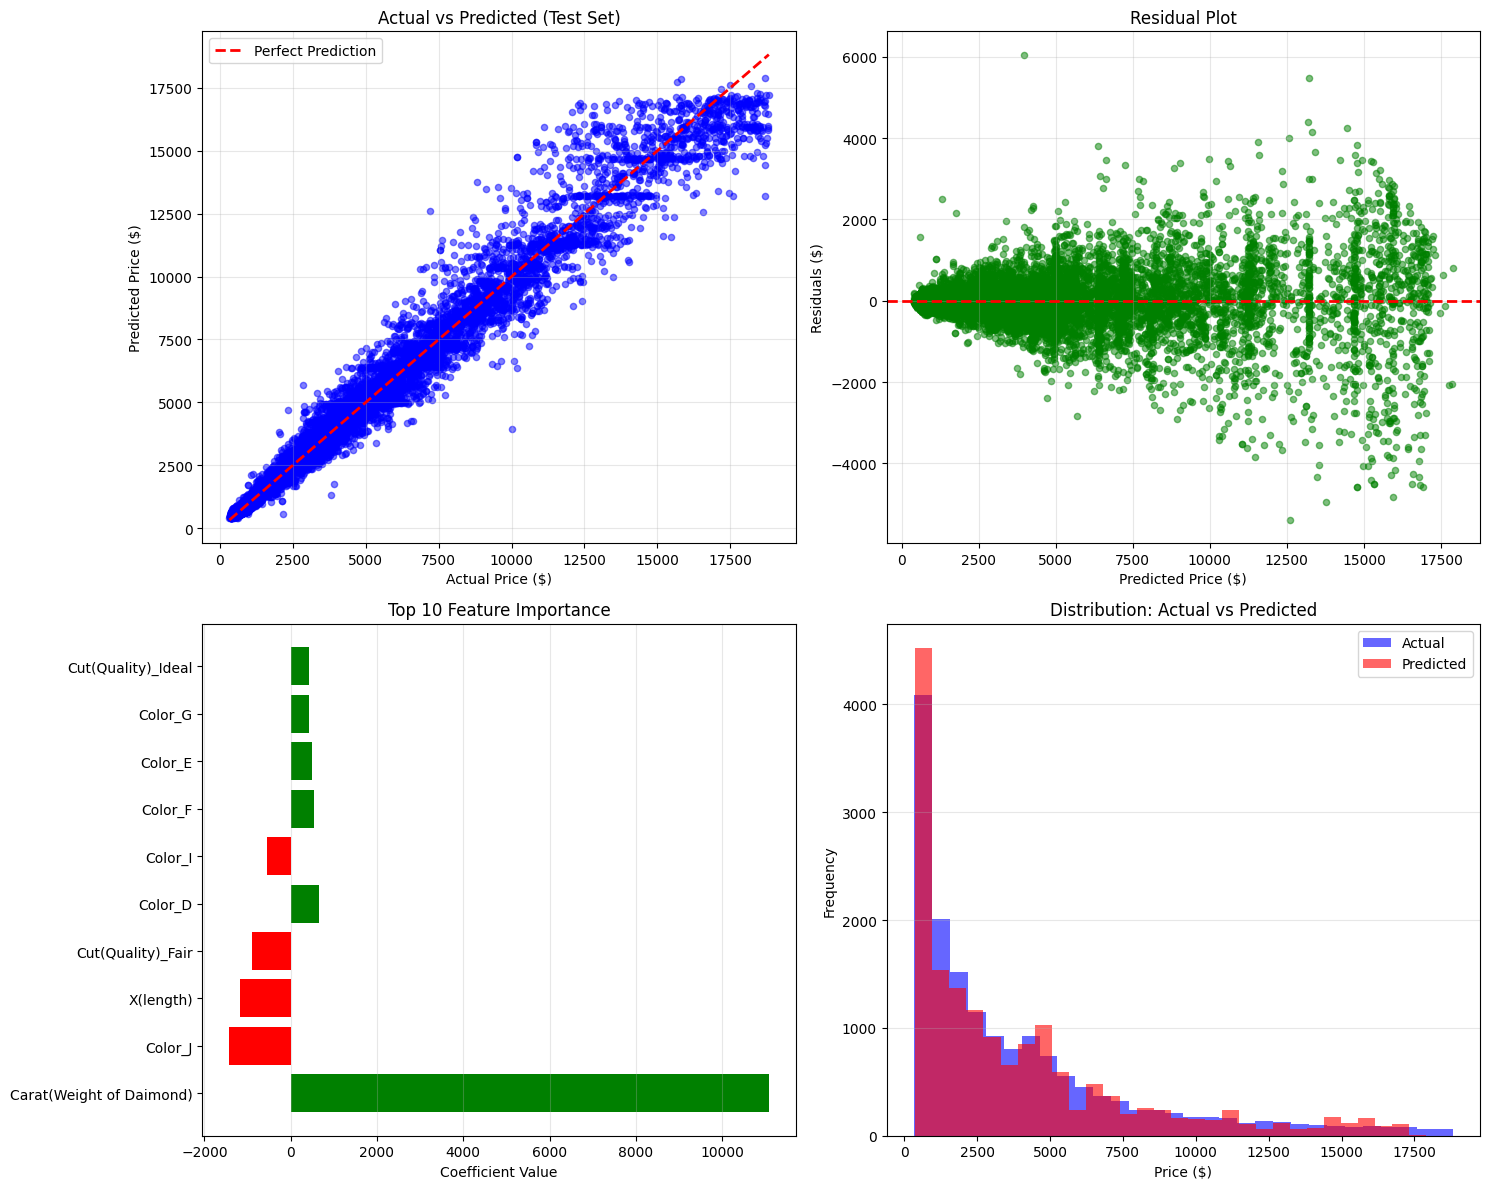

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes[0, 0].scatter(y_test, y_pred_test, alpha=0.5, s=20, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price ($)')
axes[0, 0].set_ylabel('Predicted Price ($)')
axes[0, 0].set_title('Actual vs Predicted (Test Set)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

residuals = y_test - y_pred_test
axes[0, 1].scatter(y_pred_test, residuals, alpha=0.5, s=20, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price ($)')
axes[0, 1].set_ylabel('Residuals ($)')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Feature Importance
top_10 = feature_importance.head(10)
colors = ['green' if x > 0 else 'red' for x in top_10['Coefficient']]
axes[1, 0].barh(top_10['Feature'], top_10['Coefficient'], color=colors)
axes[1, 0].set_xlabel('Coefficient Value')
axes[1, 0].set_title('Top 10 Feature Importance')
axes[1, 0].grid(True, alpha=0.3, axis='x')

axes[1, 1].hist(y_test, bins=30, alpha=0.6, label='Actual', color='blue')
axes[1, 1].hist(y_pred_test, bins=30, alpha=0.6, label='Predicted', color='red')
axes[1, 1].set_xlabel('Price ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution: Actual vs Predicted')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [41]:
feature_importance =pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': rf.feature_importances_
}).sort_values("Coefficient", key=abs, ascending=False)
print("TOP 10 features (by absolute coefficient)")
print(feature_importance.head(10).to_string(index=False))

TOP 10 features (by absolute coefficient)
                 Feature  Coefficient
Carat(Weight of Daimond)     0.632177
                Y(width)     0.265053
           ideal_encoder     0.062123
                 Color_J     0.011682
                 Color_I     0.008129
                 Color_H     0.005535
               X(length)     0.004799
                Z(Depth)     0.002936
                 Color_D     0.002578
                 Color_G     0.001535


In [53]:
#Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV


param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
}
grid = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1, random_state=42)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\lenovo\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` defaul

In [54]:
y_pred_train = grid.predict(X_train)
y_pred_test = grid.predict(X_test)

#mse, mae, r2, rmse
rf_mse_train = mean_squared_error(y_train, y_pred_train)
rf_mse_test = mean_squared_error(y_test, y_pred_test)

rf_rmse_train = np.sqrt(rf_mse_train)
rf_rmse_test = np.sqrt(rf_mse_test)

rf_mae_train = mean_absolute_error(y_train, y_pred_train)
rf_mae_test = mean_absolute_error(y_test, y_pred_test)

r2_score_train = r2_score(y_train, y_pred_train)
r2_score_test = r2_score(y_test, y_pred_test)


In [58]:
print("Training Set")

print(f" MSE Train :{rf_mse_train}")
print(f" R2 Score Train: {r2_score_train}")
print(f" MAE Train: {rf_mae_train}")
print(f" RMSE Train: {rf_rmse_train}")
print("Test Set")
print(f" RMSE Test: {rf_rmse_test}")
print(f" MSE TEST : {rf_mse_test}")
print(f" R2 Score Test: {r2_score_test}")
print(f" MAE Test: {rf_mae_test}")
#print(f"\nIntercept: ${grid.intercept_:.2f}")


Training Set
 MSE Train :1192944.851075518
 R2 Score Train: 0.9256780457660467
 MAE Train: 598.9630799309444
 RMSE Train: 1092.220147715431
Test Set
 RMSE Test: 1066.5731105448112
 MSE TEST : 1137578.200137234
 R2 Score Test: 0.9270594464668585
 MAE Test: 594.3260290473473


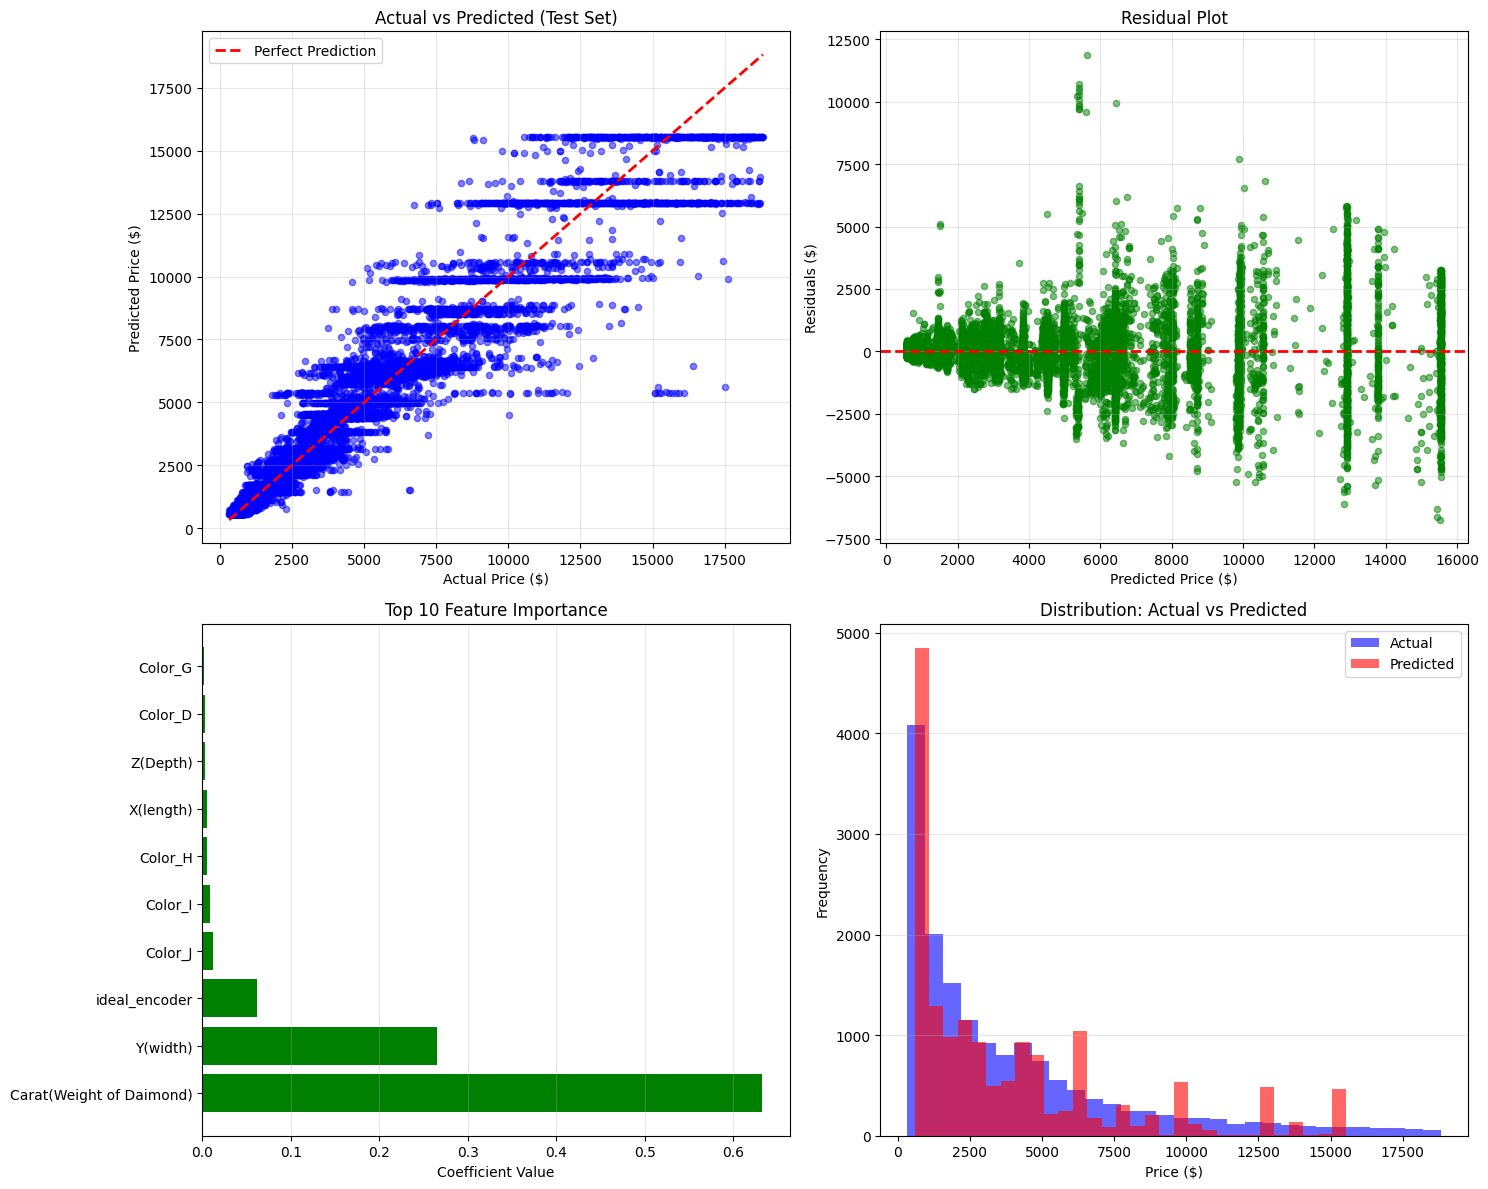

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes[0, 0].scatter(y_test, y_pred_test, alpha=0.5, s=20, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price ($)')
axes[0, 0].set_ylabel('Predicted Price ($)')
axes[0, 0].set_title('Actual vs Predicted (Test Set)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

residuals = y_test - y_pred_test
axes[0, 1].scatter(y_pred_test, residuals, alpha=0.5, s=20, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price ($)')
axes[0, 1].set_ylabel('Residuals ($)')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Feature Importance
top_10 = feature_importance.head(10)
colors = ['green' if x > 0 else 'red' for x in top_10['Coefficient']]
axes[1, 0].barh(top_10['Feature'], top_10['Coefficient'], color=colors)
axes[1, 0].set_xlabel('Coefficient Value')
axes[1, 0].set_title('Top 10 Feature Importance')
axes[1, 0].grid(True, alpha=0.3, axis='x')

axes[1, 1].hist(y_test, bins=30, alpha=0.6, label='Actual', color='blue')
axes[1, 1].hist(y_pred_test, bins=30, alpha=0.6, label='Predicted', color='red')
axes[1, 1].set_xlabel('Price ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution: Actual vs Predicted')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [ ]:
import shap
explainer = shap.TreeExplainer(rf)
sv = explainer.shap_values(X_test)
shap.summary_plot(sv[:, :, 3], X_test) 

In [ ]:
plt.show()